In [2]:
import sys
from pathlib import Path

In [3]:
class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [4]:
# Core scverse libraries
from __future__ import annotations

import anndata as ad

# Data retrieval
import pooch
import scanpy as sc
import pandas as pd

In [76]:
from src.compute.stats import stats
from data import b_naive, b_memory

data = stats.spots(b_memory)
data = stats.tracks(data)


data.drop(columns=["track_uid", "track_id", "condition", "replicate", "y_location", "x_location"], inplace=True)
data

,track_length,speed_min,speed_max,speed_mean,speed_sd,speed_median,max_distance_reached,track_start_frame,track_start_time,track_end_frame,track_end_time,mean_straight_line_speed,forward_progression_linearity,direction_mean,direction_var,mean_directional_change,mean_directional_change_rate,track_displacement,straightness_ratio,track_points
track_uid,,,,,,,,,,,,,,,,,,,,
0,192.562995,0.020141,0.229515,0.106979,0.071081,0.095415,46.094352,1,60.0,32,1920.0,0.012241,0.118236,2.255481,0.871357,80.382617,0.043216,22.767964,0.118236,31
1,122.036003,0.143331,0.267316,0.184903,0.034672,0.180029,93.985338,0,0.0,11,660.0,0.130535,0.705966,0.394393,0.237321,24.247918,0.033678,93.985338,0.770144,12
2,162.563682,0.047809,0.237677,0.135470,0.052644,0.139528,33.321433,0,0.0,21,1260.0,0.019803,0.153487,1.276848,0.793589,64.584291,0.051257,24.951444,0.153487,21
3,131.203777,0.043922,0.198376,0.115091,0.046700,0.114572,44.529236,0,0.0,19,1140.0,0.037108,0.322420,-0.042556,0.584931,45.691377,0.038076,44.529236,0.339390,20
4,114.967656,0.085788,0.253590,0.159677,0.044352,0.152967,14.492307,0,0.0,12,720.0,0.017303,0.108365,-2.161114,0.915094,116.581543,0.149464,13.496688,0.117396,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4340,0.523616,0.001195,0.003399,0.002182,0.000987,0.002067,0.287381,55,3300.0,59,3540.0,0.000878,0.402223,1.034204,0.603199,128.675573,0.428919,0.263263,0.502779,5
4341,1.183473,0.003004,0.008722,0.006575,0.003114,0.007999,0.479934,56,3360.0,59,3540.0,0.000968,0.147302,-1.421806,0.666661,94.587841,0.394116,0.232438,0.196403,4
4342,10.300524,0.171675,0.171675,0.171675,NaN,0.171675,10.300524,56,3360.0,57,3420.0,0.085838,0.500000,0.943404,0.000000,NaN,NaN,10.300524,1.000000,2


In [77]:
sc.settings.set_figure_params(dpi=100, facecolor="white")

In [78]:
# cell: #VSC-37501ce4
import numpy as np

# Preview columns to decide what goes where
print(data.columns.tolist())
print(data.dtypes)

# Separate numeric columns (features) from non-numeric columns (metadata)
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = data.select_dtypes(exclude=[np.number]).columns.tolist()

# Create AnnData: numeric columns become the X matrix, non-numeric become obs
adata = ad.AnnData(
    X=data[numeric_cols].values.astype(np.float32),
    obs=data[non_numeric_cols].reset_index(drop=True),
)

# Store feature names in var
adata.var_names = numeric_cols

# If there's a natural ID column (e.g. "TRACK_ID"), use it as obs index:
# adata.obs_names = data["TRACK_ID"].astype(str).values

adata

['track_length', 'speed_min', 'speed_max', 'speed_mean', 'speed_sd', 'speed_median', 'max_distance_reached', 'track_start_frame', 'track_start_time', 'track_end_frame', 'track_end_time', 'mean_straight_line_speed', 'forward_progression_linearity', 'direction_mean', 'direction_var', 'mean_directional_change', 'mean_directional_change_rate', 'track_displacement', 'straightness_ratio', 'track_points']
track_length                     float64
speed_min                        float64
speed_max                        float64
speed_mean                       float64
speed_sd                         float64
speed_median                     float64
max_distance_reached             float64
track_start_frame                  Int64
track_start_time                 float64
track_end_frame                    Int64
track_end_time                   float64
mean_straight_line_speed         float64
forward_progression_linearity    float64
direction_mean                   float64
direction_var           

c:\Users\modri\miniconda3\envs\peregrin\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 4345 × 20

In [79]:
# cell: #VSC-02f49219

# --- Preprocessing for migration data ---

# 1. Check for NaN/Inf and handle them
print(f"NaN count: {np.isnan(adata.X).sum()}")
print(f"Inf count: {np.isinf(adata.X).sum()}")

# Replace inf with nan, then impute nan with column median
X = adata.X.copy()
X[np.isinf(X)] = np.nan
col_medians = np.nanmedian(X, axis=0)
nan_indices = np.where(np.isnan(X))
X[nan_indices] = np.take(col_medians, nan_indices[1])
adata.X = X

print(f"After cleanup — NaN: {np.isnan(adata.X).sum()}, Inf: {np.isinf(adata.X).sum()}")

NaN count: 632
Inf count: 0
After cleanup — NaN: 0, Inf: 0


In [80]:
# 2. Store raw data before scaling
adata.raw = adata.copy()

# 3. Scale features to zero mean and unit variance
# (critical for migration data where columns have very different units/ranges)
sc.pp.scale(adata, max_value=10)

print("Scaled X stats:")
print(f"  Mean per feature ≈ {adata.X.mean(axis=0).round(2)}")
print(f"  Std per feature  ≈ {adata.X.std(axis=0).round(2)}")

Scaled X stats:
  Mean per feature ≈ [ 0. -0.  0.  0.  0.  0. -0.  0.  0.  0.  0.  0. -0. -0. -0.  0.  0. -0.
 -0. -0.]
  Std per feature  ≈ [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


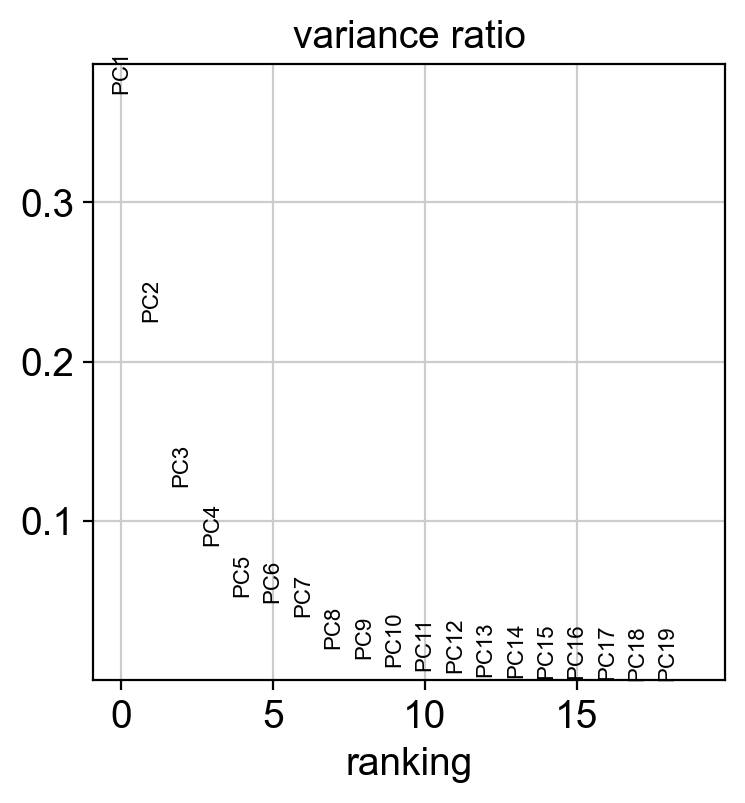

In [81]:
# 4. PCA — reduce dimensionality
n_comps = min(50, adata.n_vars - 1, adata.n_obs - 1)
sc.tl.pca(adata, n_comps=n_comps, svd_solver="arpack")

# Inspect variance explained
sc.pl.pca_variance_ratio(adata, n_pcs=n_comps, log=False)

In [82]:
# 5. Choose number of PCs (elbow method — pick where variance ratio flattens)
# Adjust n_pcs based on the variance ratio plot above
n_pcs = min(15, n_comps)

# 6. Compute neighborhood graph
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=n_pcs)

# 7. Compute UMAP embedding
sc.tl.umap(adata, min_dist=0.3, spread=1.0)

# 8. Cluster with Leiden algorithm
sc.tl.leiden(adata, resolution=0.5, flavor="igraph", n_iterations=2)

print(f"Found {adata.obs['leiden'].nunique()} clusters")
print(adata.obs['leiden'].value_counts())

Found 9 clusters
leiden
1    906
5    676
4    627
0    588
2    480
8    422
3    230
6    216
7    200
Name: count, dtype: int64


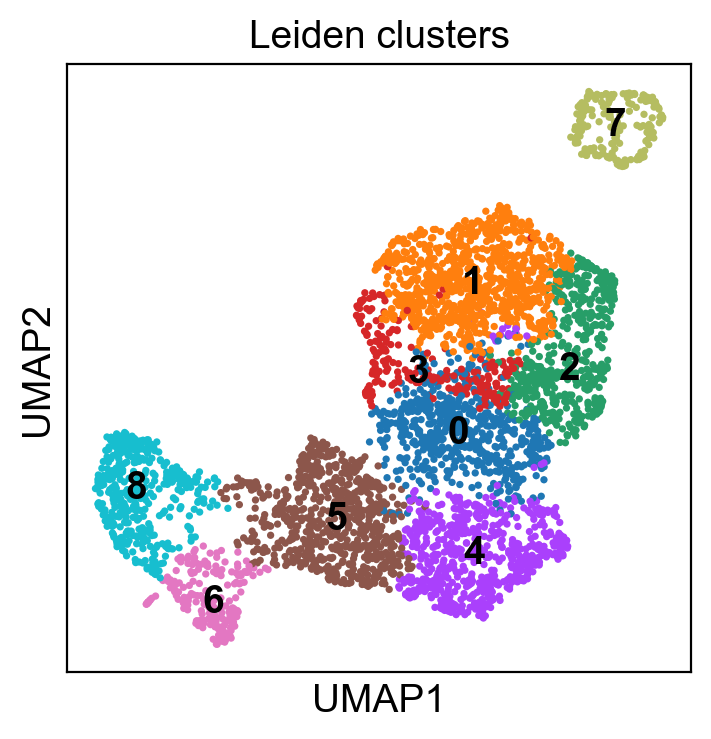

In [83]:
# 9. Plot UMAP colored by cluster
sc.pl.umap(adata, color=["leiden"], frameon=True, title="Leiden clusters", legend_loc="on data")

In [84]:
data

,track_length,speed_min,speed_max,speed_mean,speed_sd,speed_median,max_distance_reached,track_start_frame,track_start_time,track_end_frame,track_end_time,mean_straight_line_speed,forward_progression_linearity,direction_mean,direction_var,mean_directional_change,mean_directional_change_rate,track_displacement,straightness_ratio,track_points
track_uid,,,,,,,,,,,,,,,,,,,,
0,192.562995,0.020141,0.229515,0.106979,0.071081,0.095415,46.094352,1,60.0,32,1920.0,0.012241,0.118236,2.255481,0.871357,80.382617,0.043216,22.767964,0.118236,31
1,122.036003,0.143331,0.267316,0.184903,0.034672,0.180029,93.985338,0,0.0,11,660.0,0.130535,0.705966,0.394393,0.237321,24.247918,0.033678,93.985338,0.770144,12
2,162.563682,0.047809,0.237677,0.135470,0.052644,0.139528,33.321433,0,0.0,21,1260.0,0.019803,0.153487,1.276848,0.793589,64.584291,0.051257,24.951444,0.153487,21
3,131.203777,0.043922,0.198376,0.115091,0.046700,0.114572,44.529236,0,0.0,19,1140.0,0.037108,0.322420,-0.042556,0.584931,45.691377,0.038076,44.529236,0.339390,20
4,114.967656,0.085788,0.253590,0.159677,0.044352,0.152967,14.492307,0,0.0,12,720.0,0.017303,0.108365,-2.161114,0.915094,116.581543,0.149464,13.496688,0.117396,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4340,0.523616,0.001195,0.003399,0.002182,0.000987,0.002067,0.287381,55,3300.0,59,3540.0,0.000878,0.402223,1.034204,0.603199,128.675573,0.428919,0.263263,0.502779,5
4341,1.183473,0.003004,0.008722,0.006575,0.003114,0.007999,0.479934,56,3360.0,59,3540.0,0.000968,0.147302,-1.421806,0.666661,94.587841,0.394116,0.232438,0.196403,4
4342,10.300524,0.171675,0.171675,0.171675,NaN,0.171675,10.300524,56,3360.0,57,3420.0,0.085838,0.500000,0.943404,0.000000,NaN,NaN,10.300524,1.000000,2


Available features: ['track_length', 'speed_min', 'speed_max', 'speed_mean', 'speed_sd', 'speed_median', 'max_distance_reached', 'track_start_frame', 'track_start_time', 'track_end_frame', 'track_end_time', 'mean_straight_line_speed', 'forward_progression_linearity', 'direction_mean', 'direction_var', 'mean_directional_change', 'mean_directional_change_rate', 'track_displacement', 'straightness_ratio', 'track_points']


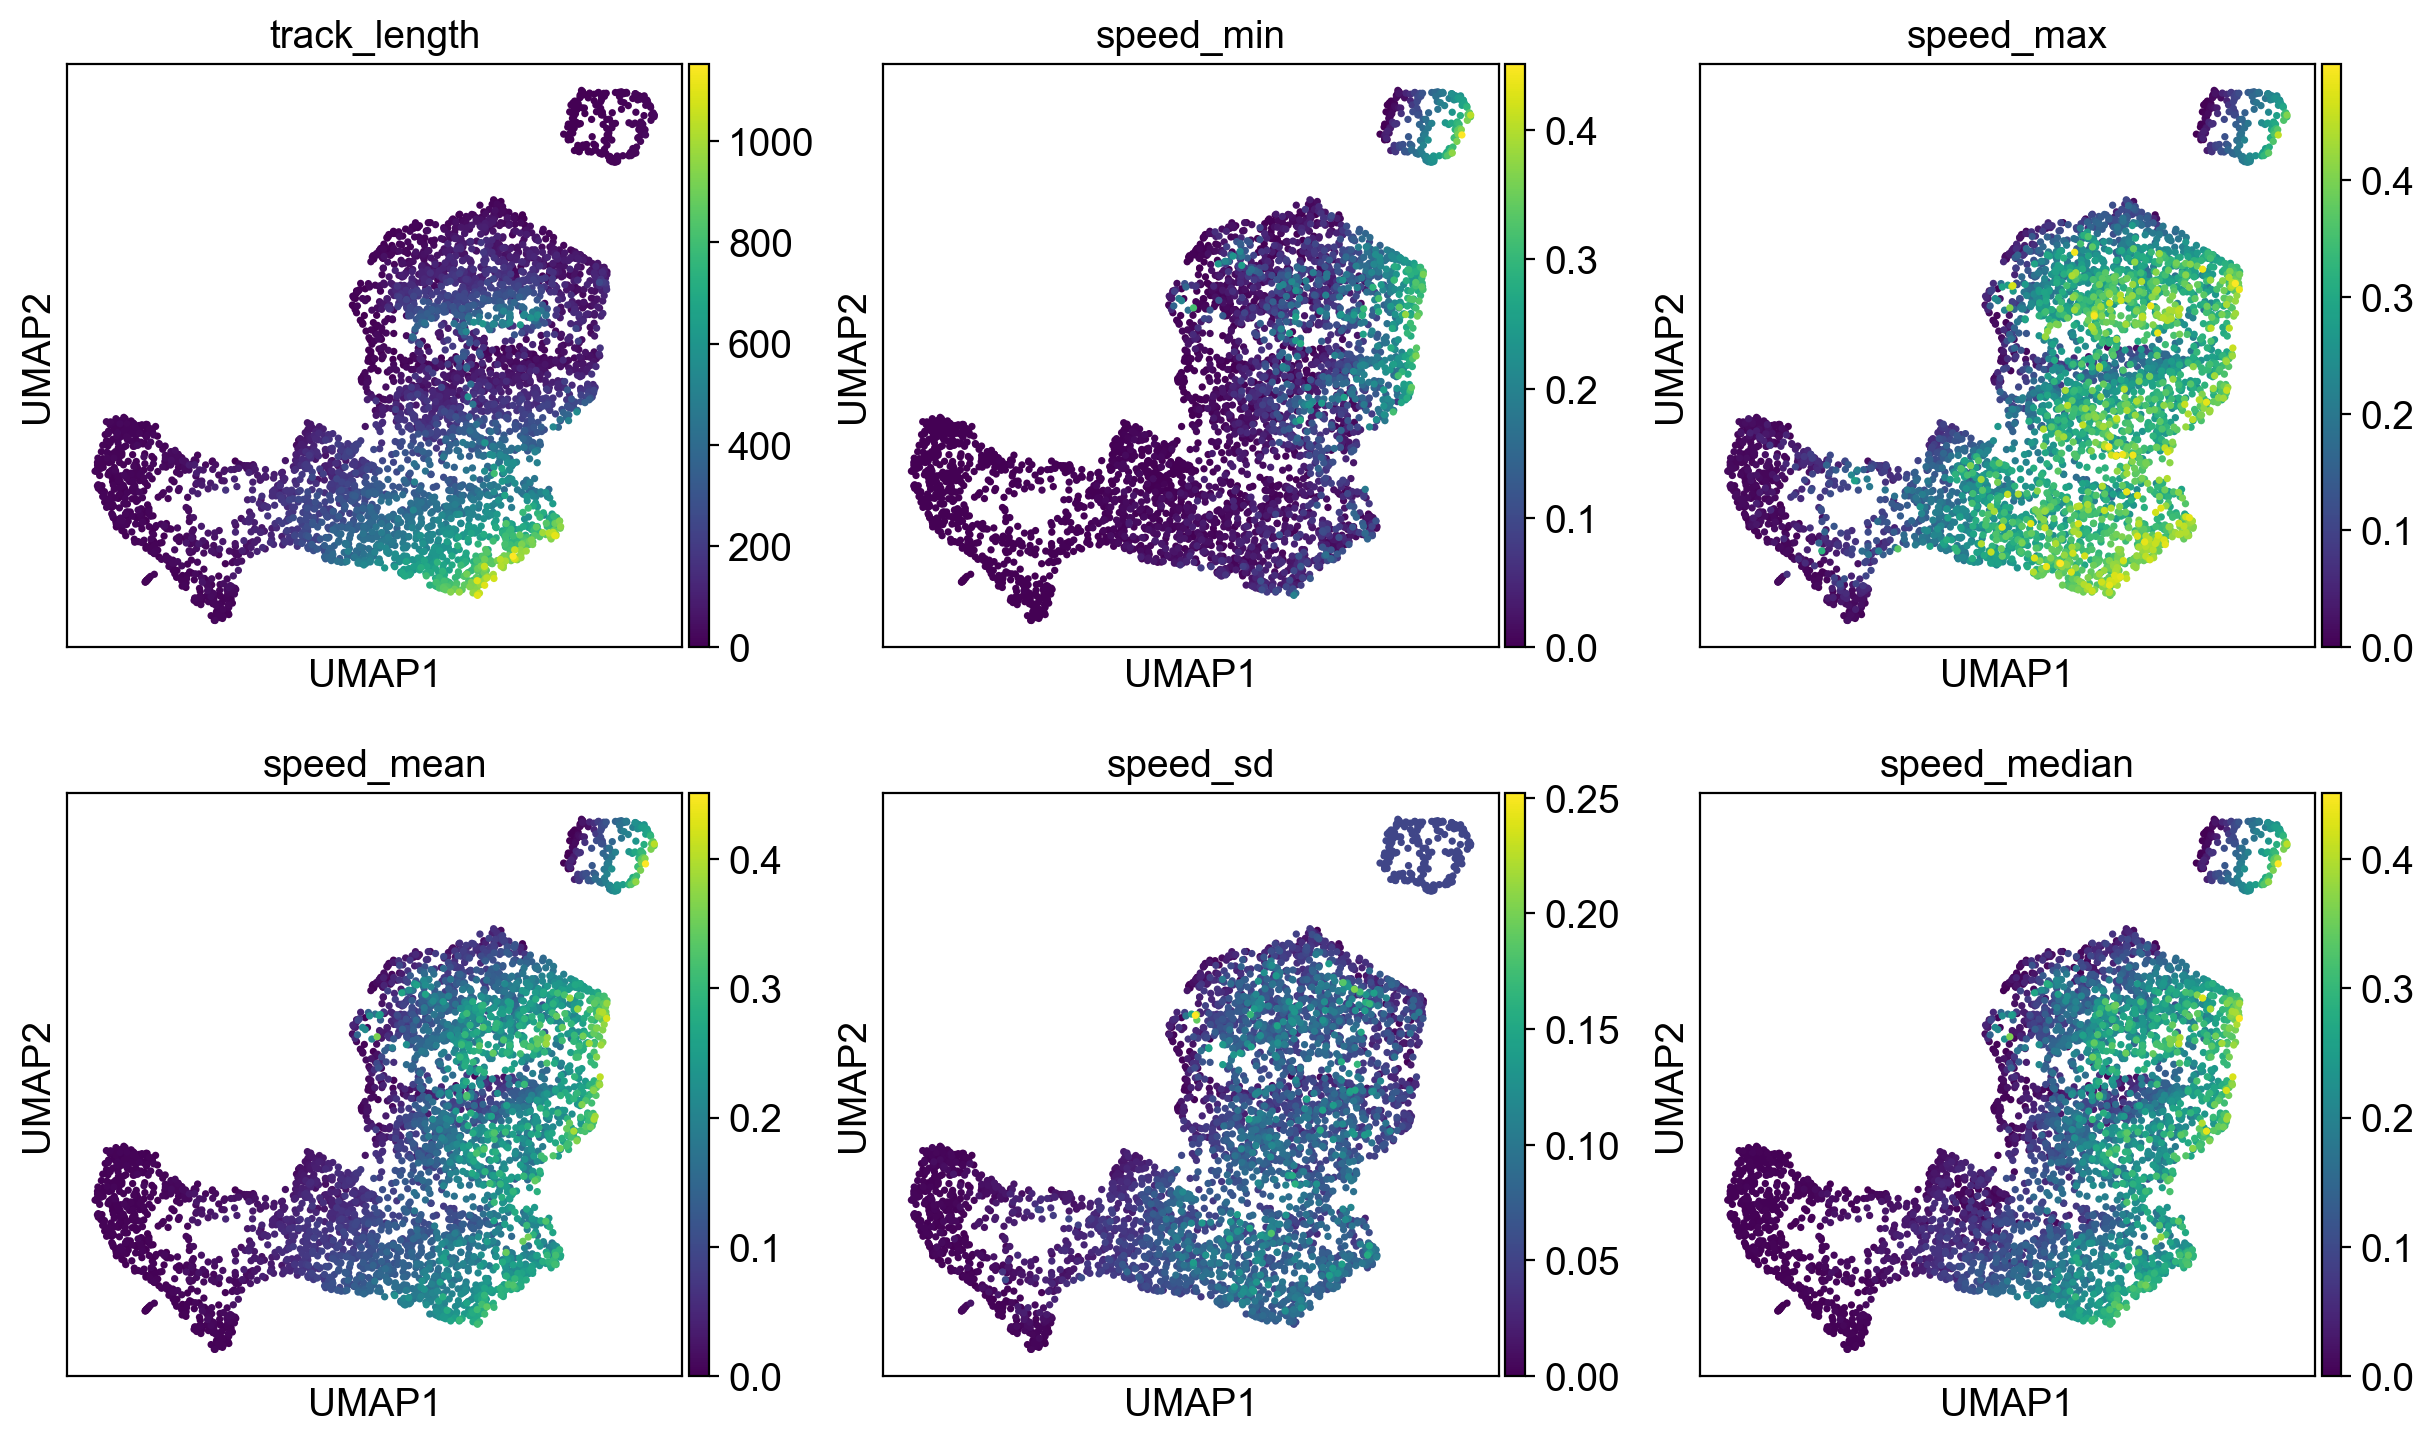

In [85]:
# 10. Plot UMAP colored by individual migration features
# Pick features of interest from your track stats
feature_cols = adata.var_names.tolist()
print("Available features:", feature_cols)

# Plot a selection (adjust names to match your actual columns)
# Common TrackMate track stats:
plot_features = [f for f in [
    "Speed mean",
    "Speed max",
    "Speed std", 
    "Track displacement",
    "Track points",
    "Track length",
    "Straightness ratio",
    "Mean straight line speed",
    "Direction var"
] if f in feature_cols]

if plot_features:
    sc.pl.umap(adata, color=feature_cols, frameon=True, ncols=3, use_raw=True)
else:
    # Fallback: plot first few numeric features
    sc.pl.umap(adata, color=feature_cols[:6], frameon=True, ncols=3, use_raw=True)

In [86]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon", use_raw=True)

c:\Users\modri\miniconda3\envs\peregrin\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\modri\miniconda3\envs\peregrin\lib\site-packages\scanpy\tools\_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
c:\Users\modri\miniconda3\envs\peregrin\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users\modri\miniconda3\envs\peregrin\lib\site-packages\scanpy\tools\_rank_genes_groups.py:484: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
c:\Users\modri\miniconda3\envs\peregrin\lib\site-packages\scanpy\tools\_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
c:\Users

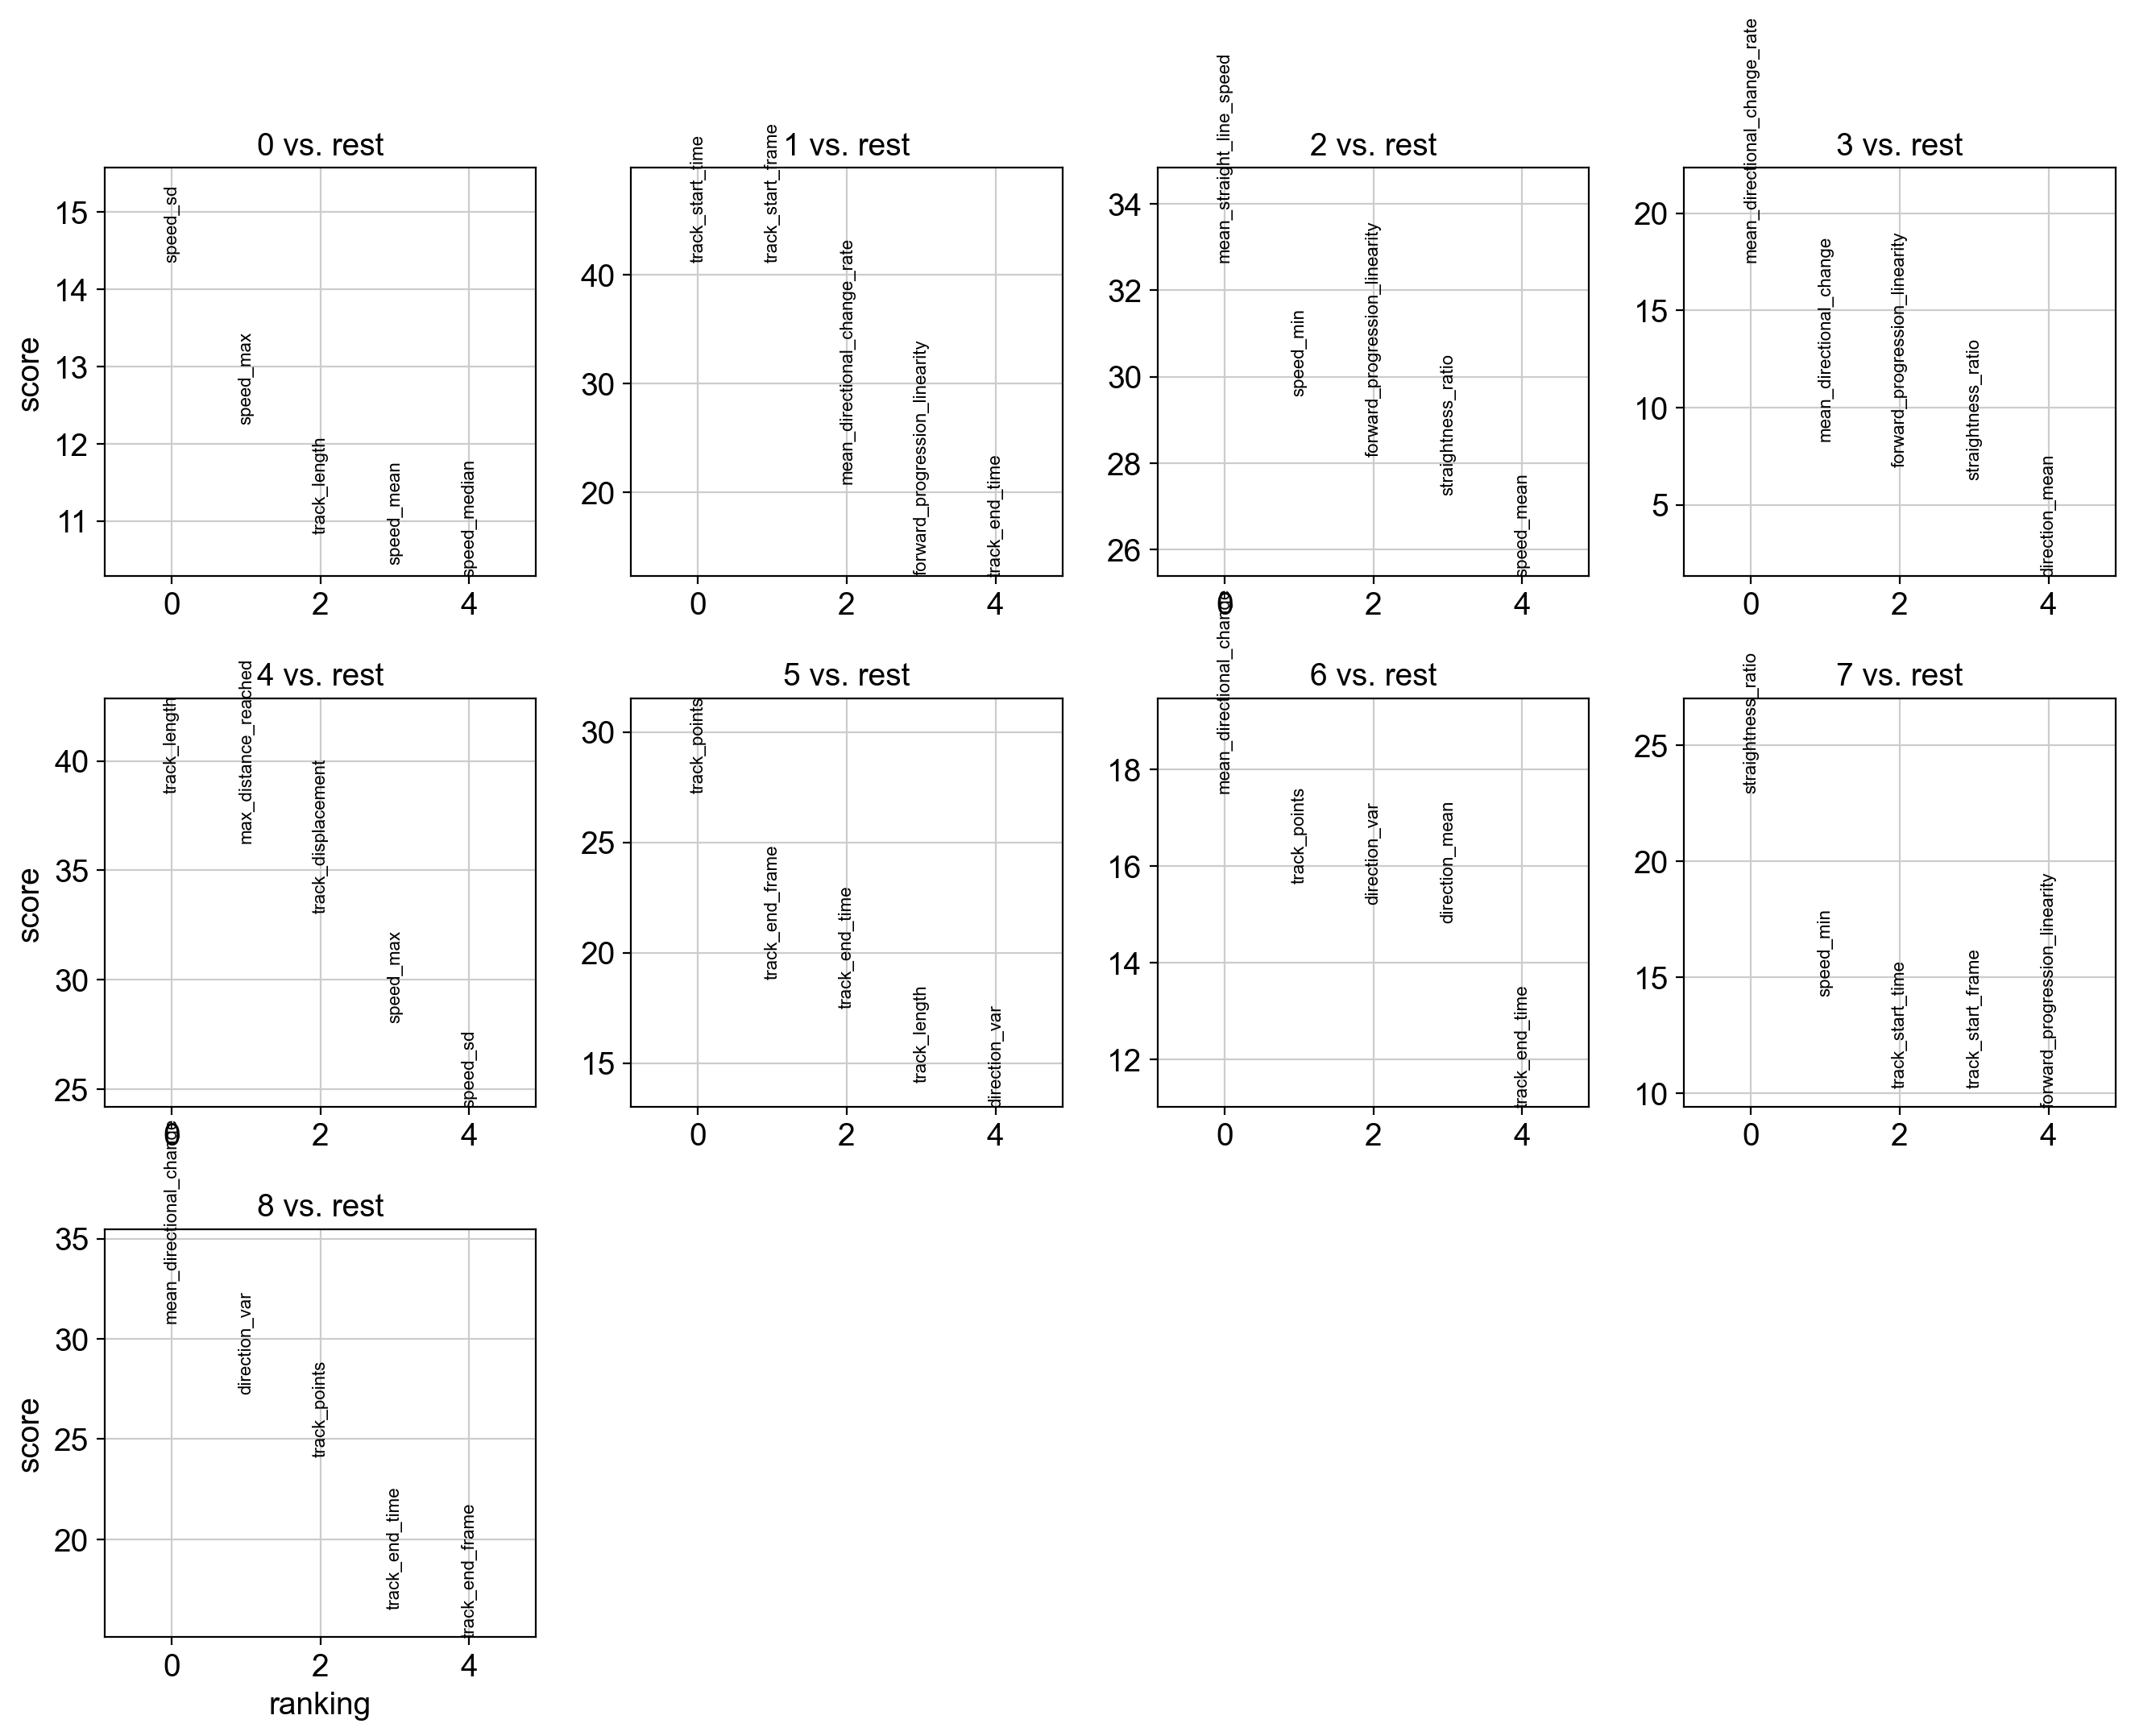

In [87]:
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)